### C'est quoi le Feature Engineering ?
C'est l'art de créer de nouvelles colonnes à partir des données existantes pour aider le modèle à mieux prédire. Les données brutes contiennent l'information, mais pas toujours sous la forme la plus utile pour le modèle.  

Ce qu'on va créer :  
On va ajouter 4 types de nouvelles variables :
1. Variables temporelles : le mois, la saison. On a vu que la nappe suit un cycle annuel. En donnant directement cette information au modèle, on l'aide à se repérer dans le calendrier.
2. Variables décalées (lags) : le niveau d'eau d'il y a 7 jours, 14 jours, 30 jours.
3. Moyennes mobiles : la pluie moyenne sur les 7, 14, 30 derniers jours. Un seul jour de pluie ne veut rien dire. C'est l'accumulation qui compte. La moyenne mobile capture ça.
4. Variables cumulées : la pluie totale et le pompage total sur les 30 derniers jours. Même logique que les moyennes mobiles, mais en version somme.

# Feature Engineering Aquifer Petrignano

## Étape 1 : Charger le dataset nettoyé

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le dataset nettoyé
df = pd.read_csv('../data/processed/Nappe_Petrignano_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Colonnes : {list(df.columns)}")

Dataset chargé : 4199 lignes, 8 colonnes
Colonnes : ['Date', 'Rainfall_Bastia_Umbra', 'Depth_to_Groundwater_P24', 'Depth_to_Groundwater_P25', 'Temperature_Bastia_Umbra', 'Temperature_Petrignano', 'Volume_C10_Petrignano', 'Hydrometry_Fiume_Chiascio_Petrignano']


## Étape 2 : Variables temporelles (mois et saison)

On extrait le **mois** et la **saison** à partir de la date.

In [2]:
# Extraire le mois (1 = janvier, 12 = décembre)
df['Mois'] = df['Date'].dt.month

# Créer la saison (1 = hiver, 2 = printemps, 3 = été, 4 = automne)
def get_saison(mois):
    if mois in [12, 1, 2]:
        return 1  # Hiver
    elif mois in [3, 4, 5]:
        return 2  # Printemps
    elif mois in [6, 7, 8]:
        return 3  # Été
    else:
        return 4  # Automne

df['Saison'] = df['Mois'].apply(get_saison)

# Vérifier
print("=== Variables temporelles créées ===\n")
print("Mois — valeurs uniques :", sorted(df['Mois'].unique()))
print("Saison — valeurs uniques :", sorted(df['Saison'].unique()))
print(f"\nAperçu :")
print(df[['Date', 'Mois', 'Saison']].head(10).to_string(index=False))

=== Variables temporelles créées ===

Mois — valeurs uniques : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Saison — valeurs uniques : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Aperçu :
      Date  Mois  Saison
2009-01-01     1       1
2009-01-02     1       1
2009-01-03     1       1
2009-01-04     1       1
2009-01-05     1       1
2009-01-06     1       1
2009-01-07     1       1
2009-01-08     1       1
2009-01-09     1       1
2009-01-10     1       1


In [3]:
df.head()

,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P24,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano,Mois,Saison
0,2009-01-01,0.0,-31.96,-31.14,5.2,4.9,-24530.688,2.4,1,1
1,2009-01-02,0.0,-32.03,-31.11,2.3,2.5,-28785.888,2.5,1,1
2,2009-01-03,0.0,-31.97,-31.07,4.4,3.9,-25766.208,2.4,1,1
3,2009-01-04,0.0,-31.91,-31.05,0.8,0.8,-27919.296,2.4,1,1
4,2009-01-05,0.0,-31.94,-31.01,-1.9,-2.1,-29854.656,2.3,1,1


## Étape 2b : Encodage cyclique du mois

Le mois est une variable **circulaire** : décembre (12) est 
juste avant janvier (1), pas loin de lui.

Si on laisse les chiffres bruts (1 à 12), le modèle pensera 
que décembre (12) est très éloigné de janvier (1).

#### Solution : transformer en sin/cos
On projette le mois sur un cercle avec deux coordonnées :
- **sin(mois)** → capture la position verticale sur le cercle
- **cos(mois)** → capture la position horizontale sur le cercle  

**Résultat** : décembre et janvier sont proches dans cet espace, et le modèle n'a plus de fausse notion de "plus grand/plus petit".

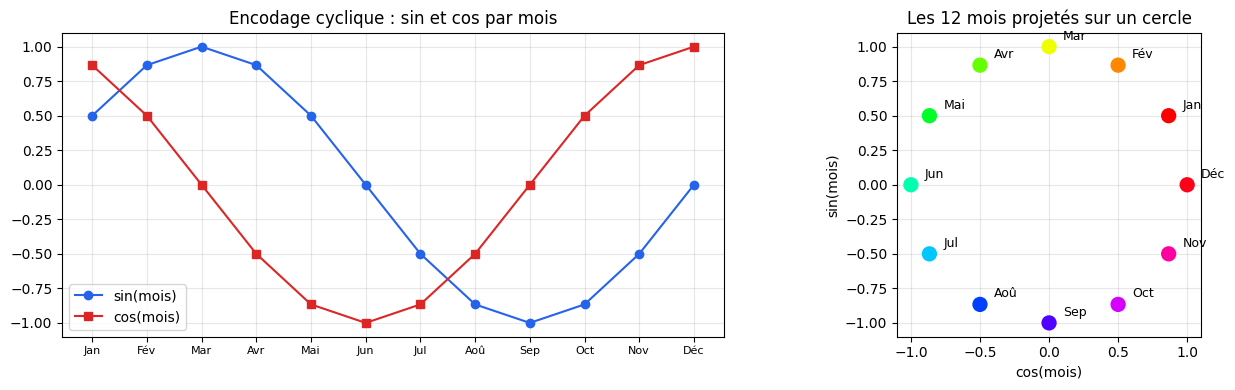


Distance entre décembre et janvier : 0.518
→ Très proches, comme attendu (max possible = 2.0)


In [4]:
# Encodage cyclique du mois
df['Mois_sin'] = np.sin(2 * np.pi * df['Mois'] / 12)
df['Mois_cos'] = np.cos(2 * np.pi * df['Mois'] / 12)

# Visualiser pour comprendre
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Graphique 1 : sin et cos par mois
mois = range(1, 13)
sin_vals = [np.sin(2 * np.pi * m / 12) for m in mois]
cos_vals = [np.cos(2 * np.pi * m / 12) for m in mois]
mois_noms = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

axes[0].plot(mois, sin_vals, 'o-', label='sin(mois)', color='#2563EB')
axes[0].plot(mois, cos_vals, 's-', label='cos(mois)', color='#DC2626')
axes[0].set_xticks(mois)
axes[0].set_xticklabels(mois_noms, fontsize=8)
axes[0].set_title('Encodage cyclique : sin et cos par mois')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : projection sur un cercle
axes[1].scatter(cos_vals, sin_vals, s=100, c=mois, cmap='hsv', zorder=5)
for i, nom in enumerate(mois_noms):
    axes[1].annotate(nom, (cos_vals[i], sin_vals[i]), 
                    textcoords="offset points", xytext=(10, 5), fontsize=9)
axes[1].set_xlabel('cos(mois)')
axes[1].set_ylabel('sin(mois)')
axes[1].set_title('Les 12 mois projetés sur un cercle')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/9_fig_encodage_cyclique.png', dpi=150, bbox_inches='tight')
plt.show()

# Vérifier que décembre et janvier sont proches
dec_sin, dec_cos = df[df['Mois']==12][['Mois_sin','Mois_cos']].iloc[0]
jan_sin, jan_cos = df[df['Mois']==1][['Mois_sin','Mois_cos']].iloc[0]
distance = np.sqrt((dec_sin - jan_sin)**2 + (dec_cos - jan_cos)**2)
print(f"\nDistance entre décembre et janvier : {distance:.3f}")
print(f"→ Très proches, comme attendu (max possible = 2.0)")

## Étape 3 : Variables décalées (lags)

Une variable décalée, c'est la valeur d'une colonne à un **moment précédent**.

au modèle, on lui fournit cette mémoire explicitement.


In [5]:
# === Lags du niveau piézométrique P24 ===
# Le niveau des jours précédents (7, 14, 30 jours avant)

df['Niveau_P24_lag7']  = df['Depth_to_Groundwater_P24'].shift(7)
df['Niveau_P24_lag14'] = df['Depth_to_Groundwater_P24'].shift(14)
df['Niveau_P24_lag30'] = df['Depth_to_Groundwater_P24'].shift(30)

# === Lags de la pluie ===
# La pluie des jours précédents (7, 14, 30 jours avant)

df['Pluie_lag7']  = df['Rainfall_Bastia_Umbra'].shift(7)
df['Pluie_lag14'] = df['Rainfall_Bastia_Umbra'].shift(14)
df['Pluie_lag30'] = df['Rainfall_Bastia_Umbra'].shift(30)

# Vérifier avec un exemple
print("=== Exemple : les 5 premières lignes où tout est disponible ===\n")
cols_to_show = ['Date', 'Depth_to_Groundwater_P24', 'Niveau_P24_lag7', 
                'Niveau_P24_lag14', 'Niveau_P24_lag30']
print(df[cols_to_show].iloc[1:30].to_string(index=False))

print(f"\n→ NaN créées par les lags : {df['Niveau_P24_lag30'].isnull().sum()}")
print(f"  (normal : les 30 premières lignes n'ont pas de 'il y a 30 jours')")

=== Exemple : les 5 premières lignes où tout est disponible ===

      Date  Depth_to_Groundwater_P24  Niveau_P24_lag7  Niveau_P24_lag14  Niveau_P24_lag30
2009-01-02                    -32.03              NaN               NaN               NaN
2009-01-03                    -31.97              NaN               NaN               NaN
2009-01-04                    -31.91              NaN               NaN               NaN
2009-01-05                    -31.94              NaN               NaN               NaN
2009-01-06                    -31.89              NaN               NaN               NaN
2009-01-07                    -31.91              NaN               NaN               NaN
2009-01-08                    -31.83           -31.96               NaN               NaN
2009-01-09                    -31.80           -32.03               NaN               NaN
2009-01-10                    -31.76           -31.97               NaN               NaN
2009-01-11                    -31.7

## Étape 4 : Moyennes mobiles (rolling means)

Une moyenne mobile calcule la **moyenne des N derniers jours**.

### Exemple concret

Si la pluie des 7 derniers jours était : 0, 5, 0, 12, 0, 0, 3 mm  
La moyenne mobile sur 7 jours = (0+5+0+12+0+0+3) / 7 = **2.86 mm/jour**

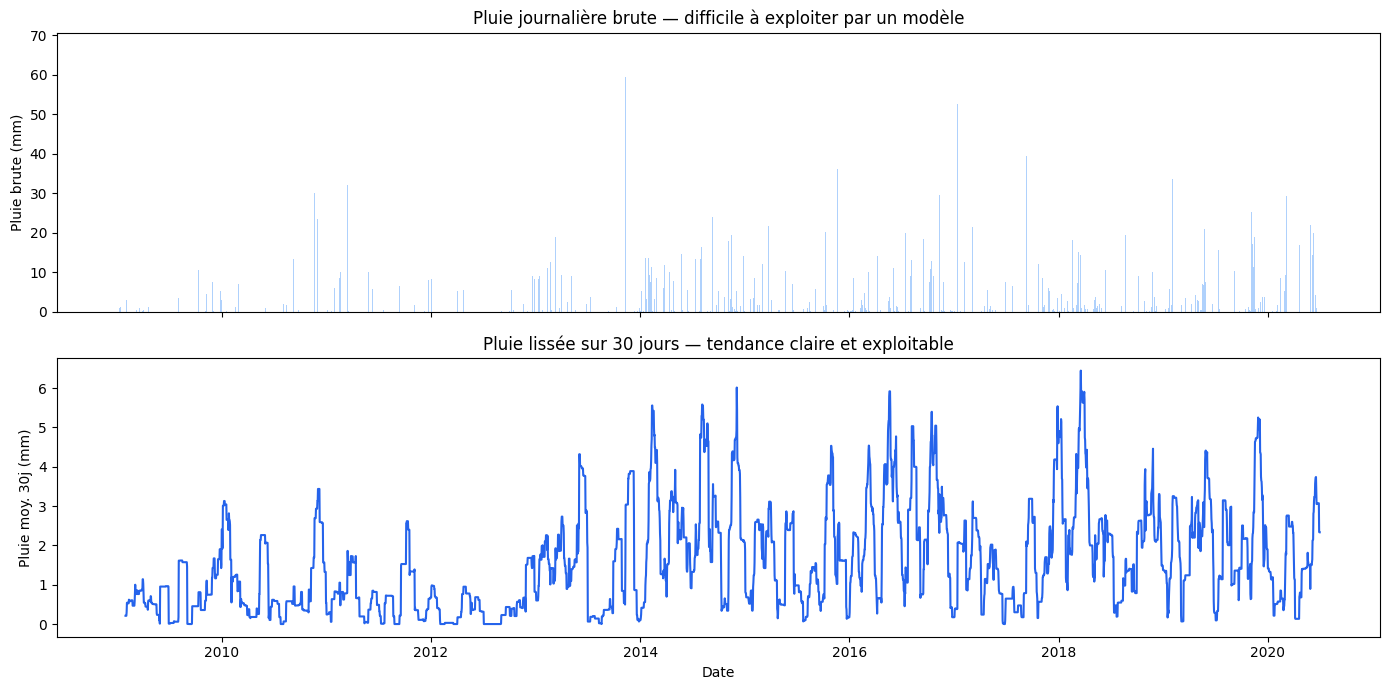

→ Figure sauvegardée dans data/processed/


In [6]:
#.rolling(window=7).mean() → pour chaque ligne, prend les 7 valeurs précédentes (la ligne actuelle + les 6 avant), calcule leur moyenne, et stocke le résultat. C'est une "fenêtre glissante" de 7 jours qui avance d'un jour à chaque ligne.
# === Moyennes mobiles de la pluie ===
df['Pluie_moy7']  = df['Rainfall_Bastia_Umbra'].rolling(window=7).mean() 
df['Pluie_moy14'] = df['Rainfall_Bastia_Umbra'].rolling(window=14).mean()
df['Pluie_moy30'] = df['Rainfall_Bastia_Umbra'].rolling(window=30).mean()

# === Moyennes mobiles du pompage ===
df['Pompage_moy7']  = df['Volume_C10_Petrignano'].rolling(window=7).mean()
df['Pompage_moy14'] = df['Volume_C10_Petrignano'].rolling(window=14).mean()
df['Pompage_moy30'] = df['Volume_C10_Petrignano'].rolling(window=30).mean()

# === Moyenne mobile du niveau P24 ===
df['Niveau_P24_moy7'] = df['Depth_to_Groundwater_P24'].rolling(window=7).mean()

# Visualiser la différence entre pluie brute et pluie lissée
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Pluie brute
axes[0].bar(df['Date'], df['Rainfall_Bastia_Umbra'], 
            color='#60A5FA', alpha=0.5, width=1)
axes[0].set_ylabel('Pluie brute (mm)')
axes[0].set_title('Pluie journalière brute — difficile à exploiter par un modèle')

# Pluie lissée (moyenne mobile 30 jours)
axes[1].plot(df['Date'], df['Pluie_moy30'], 
             color='#2563EB', linewidth=1.5)
axes[1].set_ylabel('Pluie moy. 30j (mm)')
axes[1].set_title('Pluie lissée sur 30 jours — tendance claire et exploitable')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../data/processed/10_fig_pluie_brute_vs_lissee.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

In [8]:
df.head(10)

,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P24,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano,Mois,Saison,...,Pluie_lag7,Pluie_lag14,Pluie_lag30,Pluie_moy7,Pluie_moy14,Pluie_moy30,Pompage_moy7,Pompage_moy14,Pompage_moy30,Niveau_P24_moy7
0,2009-01-01,0.0,-31.96,-31.14,5.2,4.9,-24530.688,2.4,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,0.0,-32.03,-31.11,2.3,2.5,-28785.888,2.5,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,0.0,-31.97,-31.07,4.4,3.9,-25766.208,2.4,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,0.0,-31.91,-31.05,0.8,0.8,-27919.296,2.4,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,0.0,-31.94,-31.01,-1.9,-2.1,-29854.656,2.3,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2009-01-06,0.0,-31.89,-31.00,-0.7,-0.7,-29124.576,2.3,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2009-01-07,0.0,-31.91,-30.96,1.5,-0.3,-31173.120,2.3,1,1,...,NaN,NaN,NaN,0.000000,NaN,NaN,-28164.918857,NaN,NaN,-31.944286
7,2009-01-08,0.0,-31.83,-30.94,4.3,6.6,-30232.224,2.4,1,1,...,0.0,NaN,NaN,0.000000,NaN,NaN,-28979.424000,NaN,NaN,-31.925714
8,2009-01-09,0.9,-31.80,-30.93,4.9,4.8,-30597.696,2.3,1,1,...,0.0,NaN,NaN,0.128571,NaN,NaN,-29238.253714,NaN,NaN,-31.892857
9,2009-01-10,0.0,-31.76,-30.87,1.9,4.2,-31337.280,2.3,1,1,...,0.0,NaN,NaN,0.128571,NaN,NaN,-30034.121143,NaN,NaN,-31.862857


**Ce qu'on observe :**  
La différence est frappante. En haut, du bruit quasi inexploitable. En bas, des patterns clairs et réguliers que le modèle pourra apprendre.  
Tu peux voir sur le graphique du bas que les pics de pluie lissée arrivent de manière cyclique chaque année (saisons pluvieuses), et que la période 2011-2012 a été particulièrement sèche (courbe basse), ce qui correspond exactement à la chute de la nappe qu'on avait observée.

## Étape 5 : Variables cumulées sur 30 jours

La moyenne mobile donne la **tendance**, mais la **somme cumulée** donne le **volume total** sur une période.

In [7]:
#.rolling(window=30).sum() → même principe que la moyenne mobile, mais au lieu de calculer la moyenne des 30 derniers jours, on calcule la somme. C'est le total de pluie tombée ou d'eau pompée sur le dernier mois.
# === Pluie cumulée sur 30 jours ===
df['Pluie_cum30'] = df['Rainfall_Bastia_Umbra'].rolling(window=30).sum()

# === Pompage cumulé sur 30 jours ===
df['Pompage_cum30'] = df['Volume_C10_Petrignano'].rolling(window=30).sum()

# Vérifier les nouvelles colonnes
print("=== Variables cumulées créées ===\n")
print(f"Pluie cumulée 30j — min: {df['Pluie_cum30'].min():.1f}, max: {df['Pluie_cum30'].max():.1f}")
print(f"Pompage cumulé 30j — min: {df['Pompage_cum30'].min():.0f}, max: {df['Pompage_cum30'].max():.0f}")

=== Variables cumulées créées ===

Pluie cumulée 30j — min: 0.0, max: 193.4
Pompage cumulé 30j — min: -1175378, max: -502752


## Étape 6 : Nettoyage final et sauvegarde

Les opérations de lag et de moyenne mobile créent des NaN au début du dataset (les 30 premières lignes n'ont pas de "il y a 30 jours").

On supprime ces lignes incomplètes, puis on fait le bilan de toutes les variables créées.

In [8]:
# Nombre de lignes avant nettoyage
avant = len(df)

# Supprimer les lignes avec des NaN (créées par les lags et rolling)
df = df.dropna()

# Nombre de lignes après
apres = len(df)

print("=== Nettoyage final ===\n")
print(f"Lignes avant : {avant}")
print(f"Lignes après : {apres}")
print(f"Lignes supprimées : {avant - apres} (les {avant - apres} premiers jours)")
print(f"NaN restantes : {df.isnull().sum().sum()}")

print(f"\n=== Dataset final : {df.shape[0]} lignes × {df.shape[1]} colonnes ===\n")
print("Colonnes :")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

=== Nettoyage final ===

Lignes avant : 4199
Lignes après : 4169
Lignes supprimées : 30 (les 30 premiers jours)
NaN restantes : 0

=== Dataset final : 4169 lignes × 27 colonnes ===

Colonnes :
   1. Date
   2. Rainfall_Bastia_Umbra
   3. Depth_to_Groundwater_P24
   4. Depth_to_Groundwater_P25
   5. Temperature_Bastia_Umbra
   6. Temperature_Petrignano
   7. Volume_C10_Petrignano
   8. Hydrometry_Fiume_Chiascio_Petrignano
   9. Mois
  10. Saison
  11. Mois_sin
  12. Mois_cos
  13. Niveau_P24_lag7
  14. Niveau_P24_lag14
  15. Niveau_P24_lag30
  16. Pluie_lag7
  17. Pluie_lag14
  18. Pluie_lag30
  19. Pluie_moy7
  20. Pluie_moy14
  21. Pluie_moy30
  22. Pompage_moy7
  23. Pompage_moy14
  24. Pompage_moy30
  25. Niveau_P24_moy7
  26. Pluie_cum30
  27. Pompage_cum30


## Étape 7 : Sauvegarde du dataset enrichi

On sauvegarde le dataset avec toutes les nouvelles features.

In [9]:
# Supprimer les colonnes redondantes
df_final = df.drop(columns=['Mois', 'Saison', 'Depth_to_Groundwater_P25'])

# Sauvegarder
output_path = '../data/processed/Nappe_Petrignano_features_created.csv'
df_final.to_csv(output_path, index=False)

# Bilan final
print("=== Dataset avec features sauvegardé ===\n")
print(f"Fichier : {output_path}")
print(f"Lignes  : {df_final.shape[0]}")
print(f"Colonnes: {df_final.shape[1]}")
print(f"NaN     : {df_final.isnull().sum().sum()}")

print(f"\n=== Colonnes finales ({df_final.shape[1]}) ===\n")

print("ORIGINALES (données brutes) :")
originales = ['Date', 'Rainfall_Bastia_Umbra', 'Depth_to_Groundwater_P24',
              'Temperature_Bastia_Umbra', 'Temperature_Petrignano',
              'Volume_C10_Petrignano', 'Hydrometry_Fiume_Chiascio_Petrignano']
for col in originales:
    if col in df_final.columns:
        print(f"  → {col}")

print("\nCRÉÉES (feature engineering) :")
nouvelles = [col for col in df_final.columns if col not in originales]
for col in nouvelles:
    print(f"  → {col}")

=== Dataset avec features sauvegardé ===

Fichier : ../data/processed/Nappe_Petrignano_features_created.csv
Lignes  : 4169
Colonnes: 24
NaN     : 0

=== Colonnes finales (24) ===

ORIGINALES (données brutes) :
  → Date
  → Rainfall_Bastia_Umbra
  → Depth_to_Groundwater_P24
  → Temperature_Bastia_Umbra
  → Temperature_Petrignano
  → Volume_C10_Petrignano
  → Hydrometry_Fiume_Chiascio_Petrignano

CRÉÉES (feature engineering) :
  → Mois_sin
  → Mois_cos
  → Niveau_P24_lag7
  → Niveau_P24_lag14
  → Niveau_P24_lag30
  → Pluie_lag7
  → Pluie_lag14
  → Pluie_lag30
  → Pluie_moy7
  → Pluie_moy14
  → Pluie_moy30
  → Pompage_moy7
  → Pompage_moy14
  → Pompage_moy30
  → Niveau_P24_moy7
  → Pluie_cum30
  → Pompage_cum30


## Conclusion du Feature Engineering

### Ce qu'on a créé

On est passé de **8 colonnes** (données brutes) à **24 colonnes** :

| Type | Variables créées | Pourquoi |
|---|---|---|
| Temporelles | Mois_sin, Mois_cos | Capturer la saisonnalité cyclique |
| Lags niveau P24 | lag7, lag14, lag30 | Le niveau passé prédit le niveau futur |
| Lags pluie | lag7, lag14, lag30 | L'effet de la pluie est décalé |
| Moyennes mobiles pluie | moy7, moy14, moy30 | Tendance pluviométrique lissée |
| Moyennes mobiles pompage | moy7, moy14, moy30 | Tendance de pompage lissée |
| Moyenne mobile niveau | moy7 | Tendance récente du niveau |
| Cumulées | Pluie_cum30, Pompage_cum30 | Volume total sur 30 jours |


### Prochaine étape
Modélisation : préparation des données pour le LSTM et le Random Forest, puis entraînement et comparaison des modèles.